# B-Scan Migration Playground — Subwavelength PSF TimeLapse Analysis

**Purpose:** Quantify the lateral and vertical movement detection limit of two subwavelength PEC point scatterers
using Point Spread Functions from a gprMax **zero-offset B-scan** simulation.

## Geometry

## Migration methods (all post-stack / zero-offset)
| Method | Domain | Velocity use |
|--------|--------|---------------|

## Sensitivity sweep
The right scatterer is fixed, the left scatterer moves w.r.t. a baseline study to create the timelapsed study. The right scatterer moves laterally or vertically by a fraction of the wavelength in the medium (2 lambda to 1/16 lambda). After migration the sensitivity of is determined if this movement can be detected. Both migration before and after taking the timelapse difference is tested.

In [51]:
import os, time as _time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import os
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from gprMax.gprMax import api
from tools.outputfiles_merge import merge_files
from tools.plot_Bscan import get_output_data, mpl_plot

In [68]:
# Medium
eps_r      = 3.15
v_ice      = 0.299792458 / np.sqrt(eps_r)   # m/ns ≈ 0.16892
f_c_GHz    = 1.5                              # centre frequency [GHz]
wavelength = v_ice / f_c_GHz                  # m ≈ 0.1126
v_mig      = v_ice / 2                        # exploding-reflector half-velocity [m/ns]
t0_ns      = np.sqrt(2) / f_c_GHz            # Ricker peak delay [ns] ≈ 0.943

# Survey geometry
domain_x   = 4.0
n_traces   = 380
trace_step = 0.01   # m
rx_offset  = 0.1    # m (source-receiver offset in .in file)
x_traces   = (0.1 + rx_offset / 2) + np.arange(n_traces) * trace_step   # midpoints [m]

# Scatterer geometry (shared across all datasets)
x_centre        = domain_x / 2
y_surface       = 0.9                          # air-ice interface [m from bottom]
y_scatterer     = y_surface - wavelength * 6  # cylinder centre [m from bottom]
z_scatterer     = y_surface - y_scatterer     # depth below surface [m] ≈ 0.676
radius_scat     = wavelength / 10             # radius of cylinder (point scatterer approximation) [m] ≈ 0.0028
z_top           = z_scatterer - radius_scat   # depth to cylinder top (first reflection)

separations = np.array([2, 1, 0.5, 0.25, 0.125, 0.0625]) * wavelength
x_s1_all    = np.round(x_centre - wavelength * 3 + separation, 3)
x_s2_all    = np.round(x_centre + wavelength * 3 - separation, 3)
labels      = ['Baseline', '2λ', '1λ', '½λ', '¼λ', '⅛λ', '¹⁄₁₆λ']

# Migration depth grid
z_img = np.linspace(0.0, 0.8, 160)

# Paths
STUDY_ROOT = Path(r'C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\timelapse_study')

print(f'λ_ice       = {wavelength*1e3:.1f} mm')
print(f'v_ice       = {v_ice:.5f} m/ns,  v_mig = {v_mig:.5f} m/ns')
print(f't0_ns       = {t0_ns:.3f} ns')
print(f'z_scatterer = {z_scatterer:.3f} m  (centre),  z_top = {z_top:.4f} m')
print(f'x_traces    : {x_traces[0]:.3f} → {x_traces[-1]:.3f} m  ({n_traces} traces)')

λ_ice       = 112.6 mm
v_ice       = 0.16891 m/ns,  v_mig = 0.08446 m/ns
t0_ns       = 0.943 ns
z_scatterer = 0.676 m  (centre),  z_top = 0.6644 m
x_traces    : 0.150 → 3.940 m  (380 traces)


# Input File Creation

## Calculate Geometry Factors

In [69]:
separation = np.array([0, 2, 1, 1/2, 1/4, 1/8, 1/16]) * wavelength  # m

x_centre = domain_x / 2
x_scatterer_1 = np.round(x_centre - wavelength * 3 + separation, 3) # 7 locations, scatterer that moves
x_scatterer_2 = np.round(x_centre + wavelength * 3, 3) # 7 locations, scatterer that is fixed

# check if discretisation is sufficient for CFL
dx_required = (v_ice / 4.5) / 10 # 4 GHz is the highest frequency component in the Ricker wavelet
if 0.002 < dx_required:
    print(f"Discretisation is sufficiently small")
if radius_scat < dx_required:
    print(f"Scatterer radius is smaller than discretisation")

Discretisation is sufficiently small


## Background model (no scatterers)

In [29]:
%%writefile timelapse_study/background/background.in

#title: GPR Timelapse Study - background
#domain: 4.000 1.000 0.002
#dx_dy_dz: 0.002 0.002 0.002
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.002 ice

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 background n
#messages: y

Writing timelapse_study/background/background.in


# Baseline (static scatterers)

In [30]:
%%writefile timelapse_study/baseline/baseline.in

#title: GPR Timelapse Study - baseline
#domain: 4.000 1.000 0.002
#dx_dy_dz: 0.002 0.002 0.002
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.002 ice

// Two point scatterers (PEC)
#cylinder: 1.662 0.224 0 1.662 0.224 0.002 0.0113 pec
#cylinder: 2.338 0.224 0 2.338 0.224 0.002 0.0113 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 baseline n
#messages: y

Overwriting timelapse_study/baseline/baseline.in


## 2 $\lambda$ lateral shift

In [31]:
%%writefile timelapse_study/shift_2lambda/resolution_2lambda.in

#title: GPR Timelapse Study - 2 wavelength shift
#domain: 4.000 1.000 0.002
#dx_dy_dz: 0.002 0.002 0.002
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.002 ice

// Two point scatterers (PEC)
#cylinder: 1.887 0.224 0 1.887 0.224 0.002 0.0113 pec
#cylinder: 2.338 0.224 0 2.338 0.224 0.002 0.0113 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 two_point_scatterers_2_lambda n
#messages: y

Overwriting timelapse_study/shift_2lambda/resolution_2lambda.in


## 1 $\lambda$ lateral shift

In [32]:
%%writefile timelapse_study/shift_1lambda/resolution_1lambda.in

#title: GPR Timelapse Study - 1 wavelength shift
#domain: 4.000 1.000 0.002
#dx_dy_dz: 0.002 0.002 0.002
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.002 ice

// Two point scatterers (PEC)
#cylinder: 1.775 0.224 0 1.775 0.224 0.002 0.0113 pec
#cylinder: 2.338 0.224 0 2.338 0.224 0.002 0.0113 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 two_point_scatterers_1_lambda n
#messages: y

Overwriting timelapse_study/shift_1lambda/resolution_1lambda.in


## 1/2 $\lambda$ lateral shift

In [33]:
%%writefile timelapse_study/shift_0p5lambda/resolution_0p5lambda.in

#title: GPR Timelapse Study - 0.5 wavelength shift
#domain: 4.000 1.000 0.002
#dx_dy_dz: 0.002 0.002 0.002
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.002 ice

// Two point scatterers (PEC)
#cylinder: 1.718 0.224 0 1.718 0.224 0.002 0.0113 pec
#cylinder: 2.338 0.224 0 2.338 0.224 0.002 0.0113 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 two_point_scatterers_0p5_lambda n
#messages: y

Overwriting timelapse_study/shift_0p5lambda/resolution_0p5lambda.in


## 1/4 $\lambda$ lateral shift

In [34]:
%%writefile timelapse_study/shift_0p25lambda/resolution_0p25lambda.in

#title: GPR Timelapse Study - 0.25 wavelength shift
#domain: 4.000 1.000 0.002
#dx_dy_dz: 0.002 0.002 0.002
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.002 ice

// Two point scatterers (PEC)
#cylinder: 1.690 0.224 0 1.690 0.224 0.002 0.0113 pec
#cylinder: 2.338 0.224 0 2.338 0.224 0.002 0.0113 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 two_point_scatterers_0p25_lambda n
#messages: y

Overwriting timelapse_study/shift_0p25lambda/resolution_0p25lambda.in


## 1/8 $\lambda$ lateral shift

In [35]:
%%writefile timelapse_study/shift_0p125lambda/resolution_0p125lambda.in

#title: GPR Timelapse Study - 0.125 wavelength shift
#domain: 4.000 1.000 0.002
#dx_dy_dz: 0.002 0.002 0.002
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.002 ice

// Two point scatterers (PEC)
#cylinder: 1.676 0.224 0 1.676 0.224 0.002 0.0113 pec
#cylinder: 2.338 0.224 0 2.338 0.224 0.002 0.0113 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 two_point_scatterers_0p125_lambda n
#messages: y

Overwriting timelapse_study/shift_0p125lambda/resolution_0p125lambda.in


## 1/16 $\lambda$ lateral shift

In [36]:
%%writefile timelapse_study/shift_0p0625lambda/resolution_0p0625lambda.in

#title: GPR Timelapse Study - 0.0625 wavelength shift
#domain: 4.000 1.000 0.002
#dx_dy_dz: 0.002 0.002 0.002
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.002 ice

// Two point scatterers (PEC)
#cylinder: 1.669 0.224 0 1.669 0.224 0.002 0.0113 pec
#cylinder: 2.338 0.224 0 2.338 0.224 0.002 0.0113 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 two_point_scatterers_0p0625_lambda n
#messages: y

Overwriting timelapse_study/shift_0p0625lambda/resolution_0p0625lambda.in


# Generating Geometry Files and Merged B-scans
Only uncomment and run when necessary

In [ ]:
# input_baseline      = r'timelapse_study/baseline/resolution_baseline.in'
# input_lambda_2      = r'timelapse_study/shift_2lambda/resolution_2lambda.in'
# input_lambda_1      = r'timelapse_study/shift_1lambda/resolution_1lambda.in'
# input_lambda_0p5    = r'timelapse_study/shift_0p5lambda/resolution_0p5lambda.in'
# input_lambda_0p25   = r'timelapse_study/shift_0p25lambda/resolution_0p25lambda.in'
# input_lambda_0p125  = r'timelapse_study/shift_0p125lambda/resolution_0p125lambda.in'
# input_lambda_0p0625 = r'timelapse_study/shift_0p0625lambda/resolution_0p0625lambda.in'

# api(input_lambda_2, n=1, geometry_only=True)
# api(input_lambda_1, n=1, geometry_only=True)
# api(input_lambda_0p5, n=1, geometry_only=True)
# api(input_lambda_0p25, n=1, geometry_only=True)
# api(input_lambda_0p125, n=1, geometry_only=True)
# api(input_lambda_0p0625, n=1, geometry_only=True)


In [ ]:
# filename_background    = r'timelapse_study/background/background'
# filename_baseline      = r'timelapse_study/baseline/baseline'
# filename_lambda_2      = r'timelapse_study/shift_2lambda/resolution_2lambda'
# filename_lambda_1      = r'timelapse_study/shift_1lambda/resolution_1lambda'
# filename_lambda_0p5    = r'timelapse_study/shift_0p5lambda/resolution_0p5lambda'
# filename_lambda_0p25   = r'timelapse_study/shift_0p25lambda/resolution_0p25lambda'
# filename_lambda_0p125  = r'timelapse_study/shift_0p125lambda/resolution_0p125lambda'
# filename_lambda_0p0625 = r'timelapse_study/shift_0p0625lambda/resolution_0p0625lambda'

# merge_files(filename_background, removefiles=True)
# merge_files(filename_baseline, removefiles=True)
# merge_files(filename_lambda_2, removefiles=True)
# merge_files(filename_lambda_1, removefiles=True)
# merge_files(filename_lambda_0p5, removefiles=True)
# merge_files(filename_lambda_0p25, removefiles=True)
# merge_files(filename_lambda_0p125, removefiles=True)
# merge_files(filename_lambda_0p0625, removefiles=True)


# Loading in the data and removing direct wave

In [70]:
rxnumber    = 1
rxcomponent = 'Ez'

output_background, dt = get_output_data(
    'timelapse_study/background/background_merged.out', rxnumber, rxcomponent
)

output_baseline, _ = get_output_data(
    'timelapse_study/baseline/baseline_merged.out', rxnumber, rxcomponent
)

_paths = [
    'timelapse_study/baseline/baseline_merged.out',
    'timelapse_study/shift_2lambda/resolution_2lambda_merged.out',
    'timelapse_study/shift_1lambda/resolution_1lambda_merged.out',
    'timelapse_study/shift_0p5lambda/resolution_0p5lambda_merged.out',
    'timelapse_study/shift_0p25lambda/resolution_0p25lambda_merged.out',
    'timelapse_study/shift_0p125lambda/resolution_0p125lambda_merged.out',
    'timelapse_study/shift_0p0625lambda/resolution_0p0625lambda_merged.out',
]
raw_outputs      = [get_output_data(p, rxnumber, rxcomponent)[0] for p in _paths]
outputs_static   = [r - output_background for r in raw_outputs]      # background-subtracted
outputs          = [r - output_baseline for r in raw_outputs[1:]]     # baseline-subtracted / timelapsed data

dt_ns   = dt * 1e9
n_t     = outputs[0].shape[0]
time_ns = np.arange(n_t) * dt_ns

# Convenience lists for the visualisation cells below
data_pre = [('Background', output_background)] + list(zip(labels, raw_outputs))
data_static = list(zip(labels, outputs_static))
data     = list(zip(labels[1:], outputs))

labels = labels[1:]

print(f'dt = {dt_ns:.6f} ns,  n_t = {n_t},  t_max = {time_ns[-1]:.2f} ns')
print(f'Data shape (n_t × n_tr): {outputs[0].shape}  ({n_t} time samples × {n_traces} traces)')

dt = 0.004717 ns,  n_t = 4241,  t_max = 20.00 ns
Data shape (n_t × n_tr): (4241, 380)  (4241 time samples × 380 traces)


# Visualisation

C:\Users\Administrator\AppData\Local\Temp\ipykernel_20812\1314390544.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


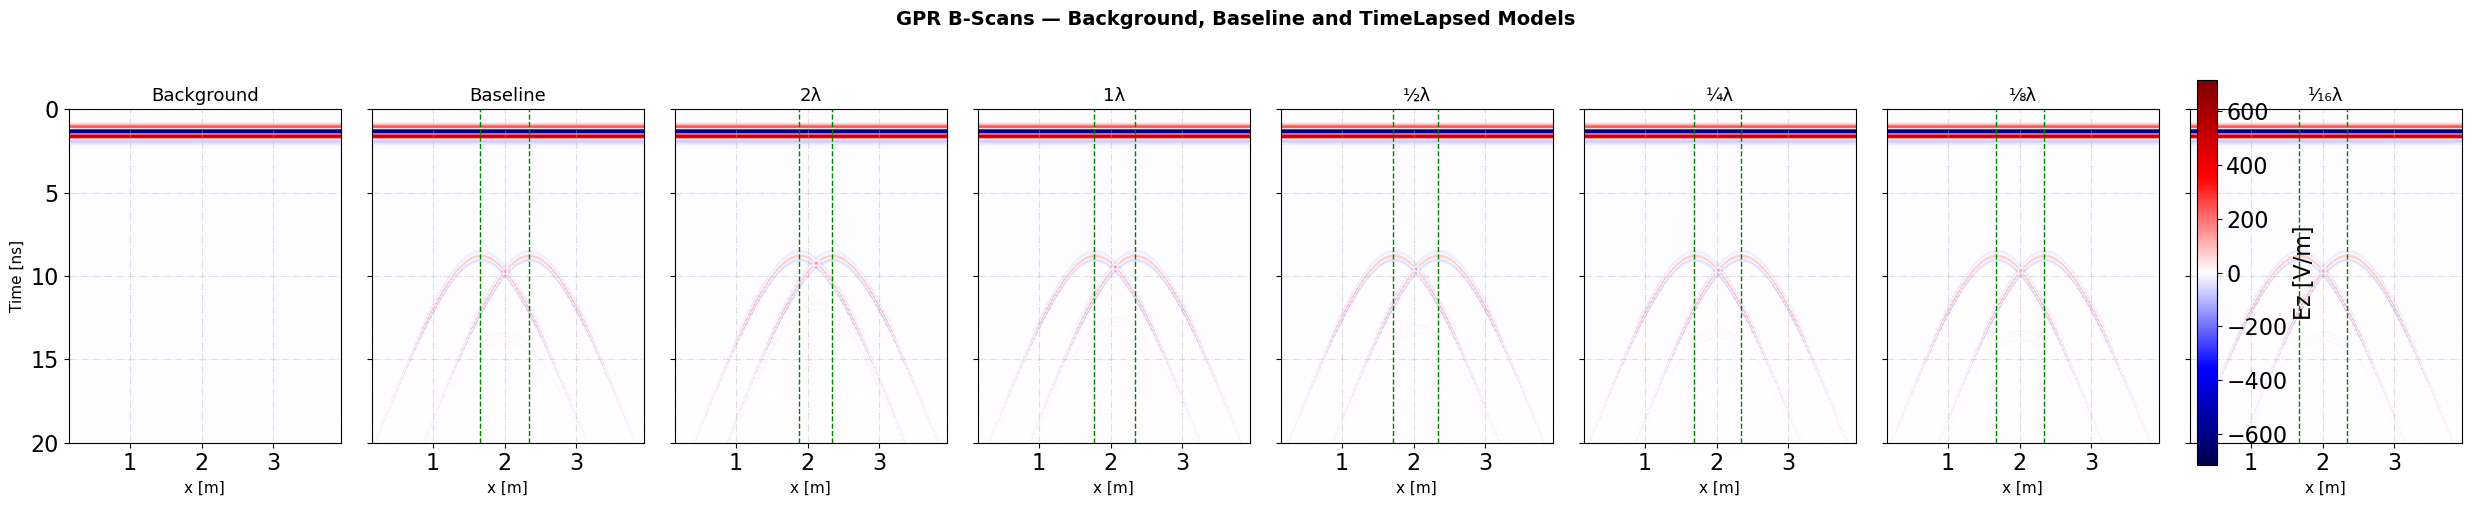

In [55]:
extent_bscan = [x_traces[0], x_traces[-1], time_ns[-1], 0]

fig, axes = plt.subplots(1, 8, figsize=(25, 5), facecolor='w', sharey=True)
vmax = max(np.abs(d).max() for _, d in data_pre)

for i, (ax, (title, d)) in enumerate(zip(axes, data_pre)):
    im = ax.imshow(d, aspect='auto', cmap='seismic', extent=extent_bscan,
                   interpolation='nearest', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('x [m]', fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel('Time [ns]', fontsize=11)
    ax.grid(linestyle='-.', alpha=0.4)
    if i > 0:  # skip Background panel (no scatterers)
        ax.axvline(x_scatterer_1[i - 1], color='green', linestyle='--', linewidth=1)
        ax.axvline(x_scatterer_2, color='green', linestyle='--', linewidth=1)

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label='Ez [V/m]')
fig.suptitle('GPR B-Scans — Background, Baseline and TimeLapsed Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_20812\1725382490.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


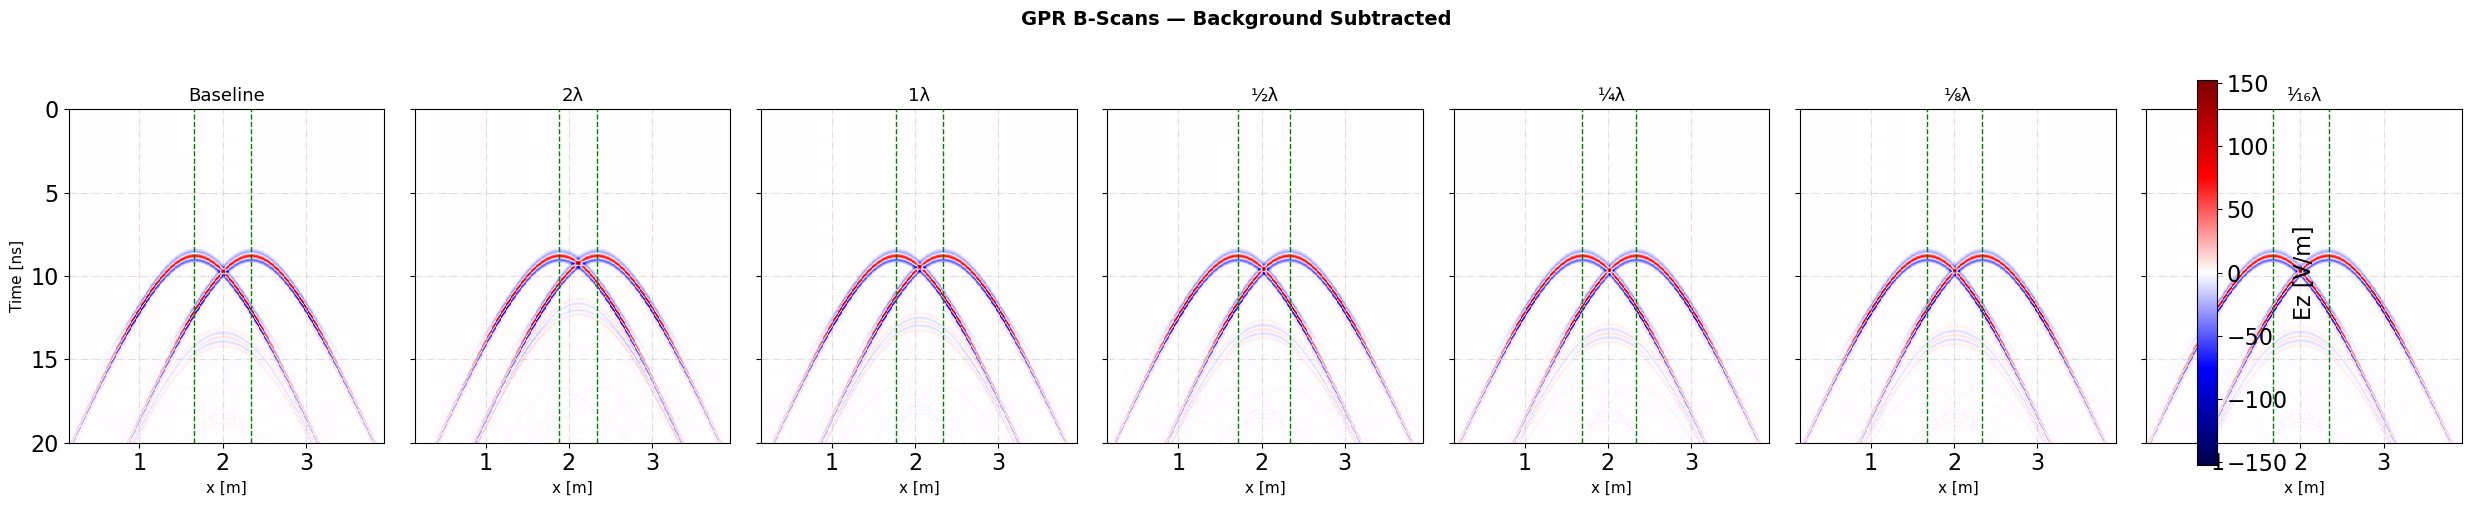

In [56]:
fig, axes = plt.subplots(1, 7, figsize=(25, 5), facecolor='w', sharey=True)
vmax = max(np.abs(d).max() for _, d in data_static)

for i, (ax, (title, d)) in enumerate(zip(axes, data_static)):
    im = ax.imshow(d, aspect='auto', cmap='seismic', extent=extent_bscan,
                   interpolation='nearest', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('x [m]', fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel('Time [ns]', fontsize=11)
    ax.grid(linestyle='-.', alpha=0.4)
    ax.axvline(x_scatterer_1[i], color='green', linestyle='--', linewidth=1)
    ax.axvline(x_scatterer_2, color='green', linestyle='--', linewidth=1)

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label='Ez [V/m]')
fig.suptitle('GPR B-Scans — Background Subtracted', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_20812\3125839590.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


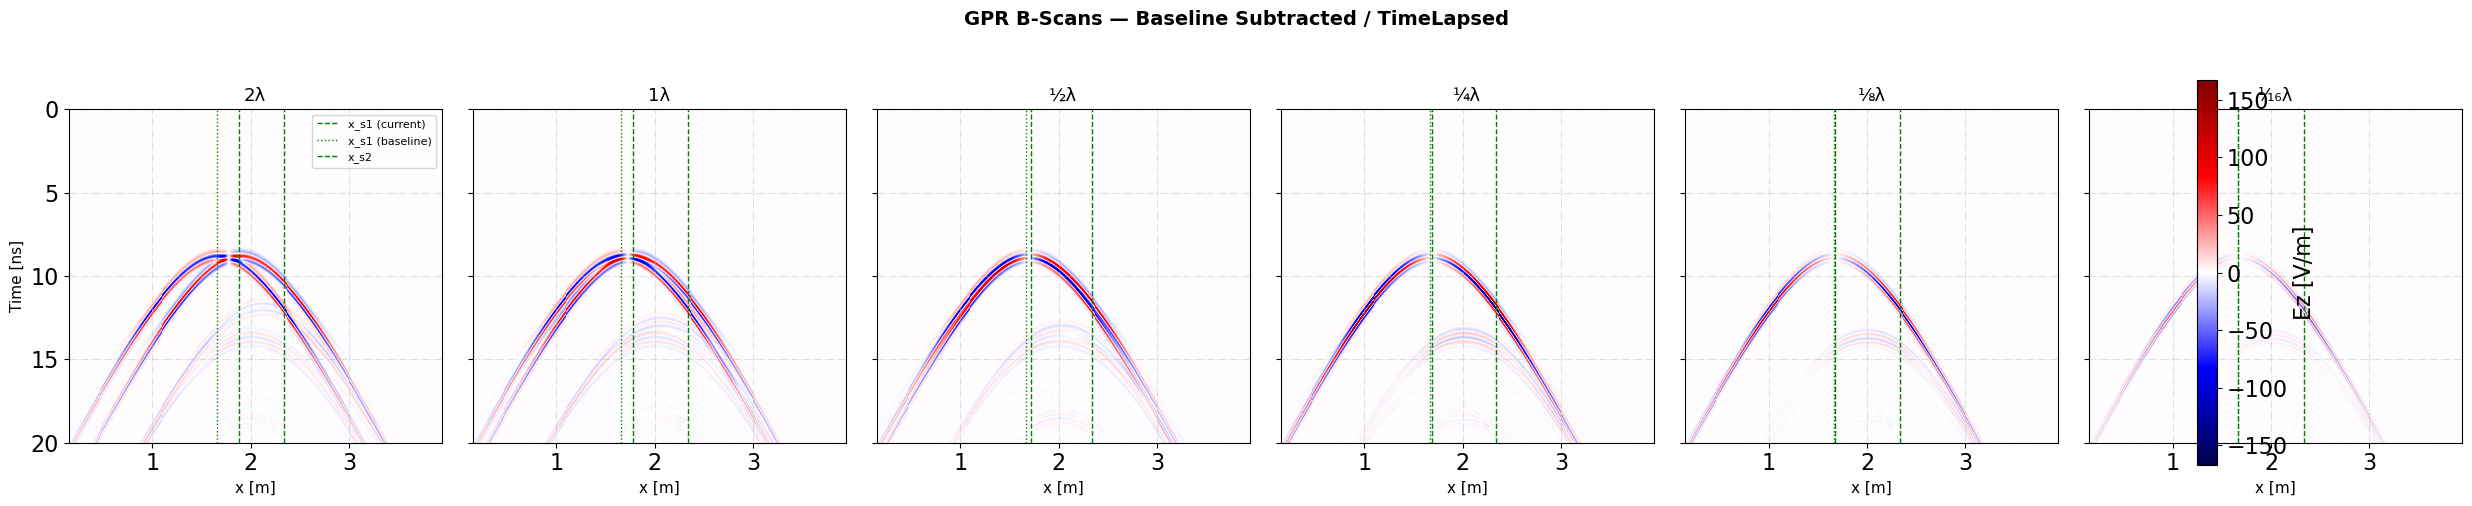

In [57]:
fig, axes = plt.subplots(1, 6, figsize=(25, 5), facecolor='w', sharey=True)
vmax = max(np.abs(d).max() for _, d in data)

for i, (ax, (title, d)) in enumerate(zip(axes, data)):
    im = ax.imshow(d, aspect='auto', cmap='seismic', extent=extent_bscan,
                   interpolation='nearest', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('x [m]', fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel('Time [ns]', fontsize=11)
    ax.grid(linestyle='-.', alpha=0.4)
    ax.axvline(x_scatterer_1[i + 1], color='green', linestyle='--', linewidth=1, label='x_s1 (current)')
    ax.axvline(x_scatterer_1[0],     color='green', linestyle=':',  linewidth=1, label='x_s1 (baseline)')
    ax.axvline(x_scatterer_2,        color='green', linestyle='--', linewidth=1, label='x_s2')

axes[0].legend(fontsize=8, loc='upper right')

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label='Ez [V/m]')
fig.suptitle('GPR B-Scans — Baseline Subtracted / TimeLapsed', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Kirchhoff Migration

Delay-and-sum migration via the **PyLops zero-offset Kirchhoff operator**.  
Each dataset is preprocessed (tapering + t0 shift — see cell above) before being migrated.  
Green stars mark the true cylinder-top positions.

In [58]:
def PylopsKirchoffMigration(data, t, x, vel_model, z,wav='Ricker', wavcenter='Center',f0=0.08 ,recs = None, srcs = None, mode='analytic', dynamic=False,
aperture=None, angleaperture=None, return_op=False):
    """
    Perform Kirchhoff migration using PyLops zero offset operator. pass ns, gHz and meter 
    """
    import numpy as np
    import KirchhoffPylopsZeroOffset
    import importlib
    importlib.reload(KirchhoffPylopsZeroOffset)
    from pylops.utils.wavelets import ricker
    
    # For zero-offset, srcs = recs
    rx = x
    rz = np.zeros_like(rx)
    recs = np.vstack((rx, rz))
    srcs = recs

    # Handle wavelet selection
    if wav == 'Ricker':
        # Generate a short wavelet: 6 cycles, centered at zero, dependent on f0
        n_cycles = 6
        period_ns = 1.0 / f0 # t in ns, f0 in GHz
        wav_duration = n_cycles * period_ns # total duration in ns
        n_wav_samples = int(np.ceil(wav_duration / (t[1] - t[0])))
        # Ensure odd number for center
        if n_wav_samples % 2 == 0:
            n_wav_samples += 1
        wav_arr, trick, wcenter = ricker(t[0:n_wav_samples], f0=f0)
    else:
        wav_arr = wav
        
    if wavcenter == 'Center':
        wavcenter = wcenter

    # Build Zero Offset Kirchhoff operator
    K = KirchhoffPylopsZeroOffset.Kirchhoff(
        z=z, x=x, t=t,
        srcs=srcs, recs=recs,
        vel=vel_model,
        wav=wav_arr, wavcenter=wavcenter,
        mode=mode, dynamic=dynamic,
        aperture=aperture, angleaperture=angleaperture
    )

    d = data.flatten()
    print("d.shape:", d.shape, "K dimension:", K.shape)

    # Migrate: apply adjoint
    m = K.H @ d
    
    # Reshape to (nz, nx)
    m = m.reshape(len(x), len(z)).T
    
    if return_op:
        return m, K
    return m

## Tapering & t0 Shift

Two pre-processing steps applied to every B-scan before migration:

| Step | Purpose |
|------|---------|
| **Exponential decay taper** (`taper_decay_ns`) | Suppresses late arrivals, emphasises hyperbola apices |
| **Cosine end taper** (`taper_end_ns`) | Zeros the final portion of each trace to remove hyperbola tails |
| **t0 shift** | Removes the Ricker wavelet's built-in peak delay so that t = 0 aligns with the surface |

Adjust the parameters in the cell below and re-run to see their effect on the B-scan.

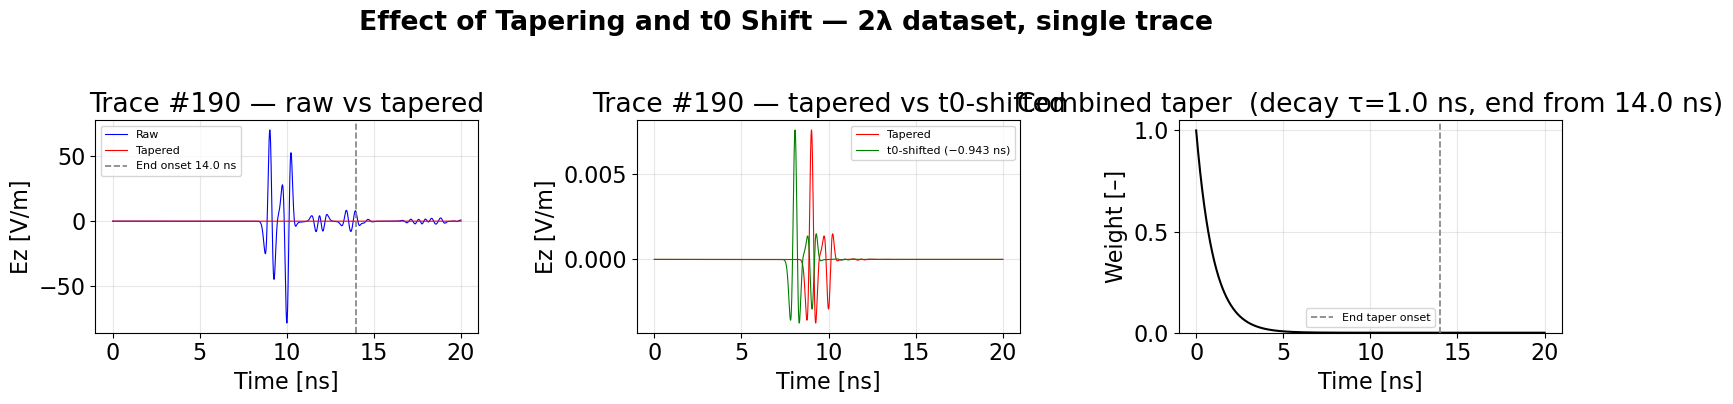

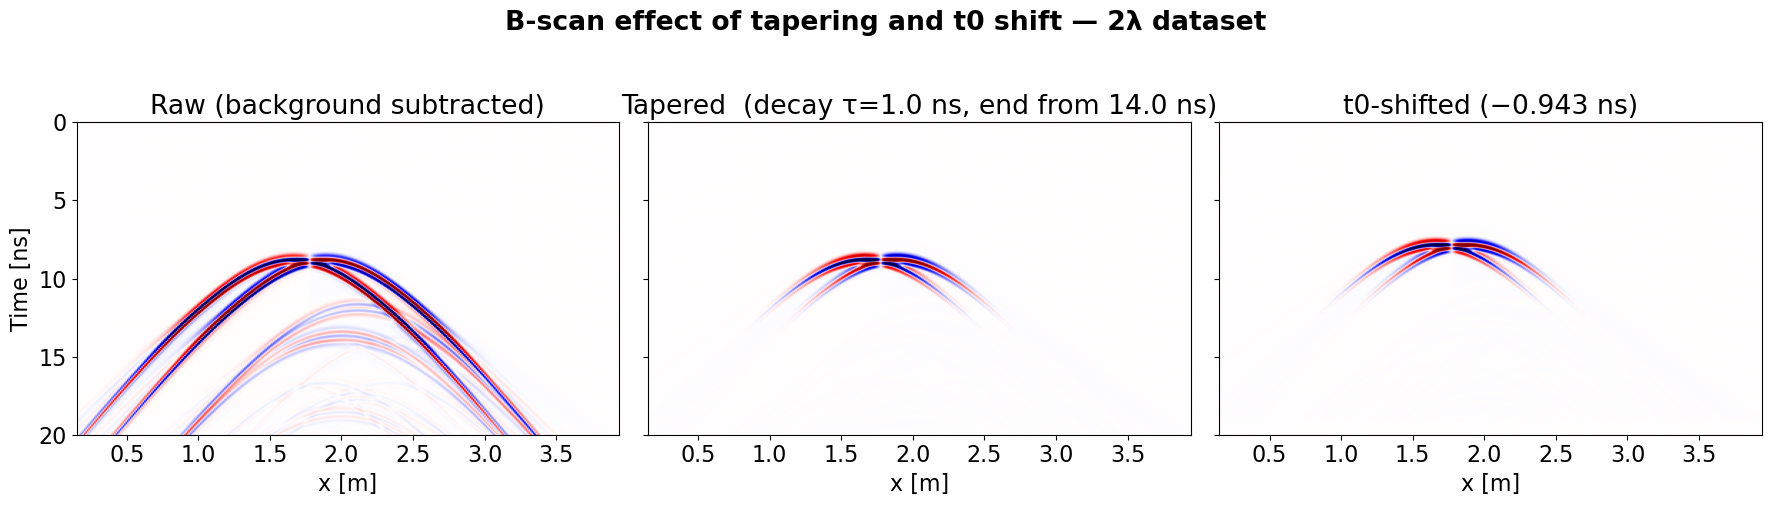

In [59]:
# ── Taper & t0-shift parameters ───────────────────────────────────────────────
taper_end_ns   = 14.0   # cosine ramp onset [ns]: zeros hyperbola tails beyond this time
taper_decay_ns = 1.0    # exponential decay time constant [ns]: de-emphasises late arrivals
ANGLE_AP       = 40     # Kirchhoff aperture half-angle [degrees]

# ── Functions ─────────────────────────────────────────────────────────────────
def make_end_taper(n_samples, taper_samples):
    """Unity everywhere, then half-cosine 1→0 over the last `taper_samples`."""
    win = np.ones(n_samples)
    if taper_samples > 0:
        ramp = 0.5 * (1 + np.cos(np.pi * np.arange(taper_samples) / taper_samples))
        win[-taper_samples:] = ramp
    return win

def make_decay_taper(time_ns, tau_ns):
    """Exponential decay starting at 1.0 (t=0) with time constant tau_ns."""
    return np.exp(-time_ns / tau_ns)

def preprocess(data_nt_ntr, dt_ns, t0_ns, time_ns):
    """
    Prepare a B-scan for Kirchhoff migration.
    Input:  data_nt_ntr  (n_t, n_tr)  — background-subtracted B-scan
    Returns tapered (n_tr, n_t) and t0-shifted (n_tr, n_t) arrays.
    """
    bscan   = data_nt_ntr.T.copy()                              # → (n_tr, n_t)
    n_t     = bscan.shape[1]
    w_end   = make_end_taper(n_t, int(round(taper_end_ns / dt_ns)))
    w_decay = make_decay_taper(time_ns, taper_decay_ns)
    tapered = bscan * (w_end * w_decay)[np.newaxis, :]
    t0_samp = int(round(t0_ns / dt_ns))
    shifted = np.roll(tapered, -t0_samp, axis=1)
    shifted[:, -t0_samp:] = 0.0
    return tapered, shifted

# ── Visualise effect on the 2λ dataset ────────────────────────────────────────
_demo = outputs[0]    # (n_t, n_tr)
_raw_tr, _shifted = preprocess(_demo, dt_ns, t0_ns, time_ns)
_tapered = _raw_tr   # preprocess returns tapered as first output

w_end_vis   = make_end_taper(n_t, int(round(taper_end_ns   / dt_ns)))
w_decay_vis = make_decay_taper(time_ns, taper_decay_ns)
taper_combined = w_end_vis * w_decay_vis

mid_tr = n_traces // 2   # representative central trace

# --- Row 1: single-trace before/after ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(time_ns, _demo[:, mid_tr], 'b', lw=0.8, label='Raw')
axes[0].plot(time_ns, _tapered[mid_tr], 'r', lw=0.8, label='Tapered')
axes[0].axvline(taper_end_ns, color='gray', ls='--', lw=1.2, label=f'End onset {taper_end_ns} ns')
axes[0].set(xlabel='Time [ns]', ylabel='Ez [V/m]', title=f'Trace #{mid_tr} — raw vs tapered')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(time_ns, _tapered[mid_tr], 'r', lw=0.8, label='Tapered')
axes[1].plot(time_ns, _shifted[mid_tr], 'g', lw=0.8, label=f't0-shifted (−{t0_ns:.3f} ns)')
axes[1].set(xlabel='Time [ns]', ylabel='Ez [V/m]', title=f'Trace #{mid_tr} — tapered vs t0-shifted')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].plot(time_ns, taper_combined, 'k', lw=1.5)
axes[2].axvline(taper_end_ns, color='gray', ls='--', lw=1.2, label=f'End taper onset')
axes[2].set(xlabel='Time [ns]', ylabel='Weight [–]',
            title=f'Combined taper  (decay τ={taper_decay_ns} ns, end from {taper_end_ns} ns)',
            ylim=(0, 1.05))
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle('Effect of Tapering and t0 Shift — 2λ dataset, single trace', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# --- Row 2: full B-scan comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
kw = dict(aspect='auto', cmap='seismic', extent=extent_bscan, origin='upper')

vmax0 = np.max(np.abs(_demo)) * 0.5
axes[0].imshow(_demo, **kw, vmin=-vmax0, vmax=vmax0)
axes[0].set(title='Raw (background subtracted)', xlabel='x [m]', ylabel='Time [ns]')

vmax1 = np.max(np.abs(_tapered)) * 0.5
axes[1].imshow(_tapered.T, **kw, vmin=-vmax1, vmax=vmax1)
axes[1].set(title=f'Tapered  (decay τ={taper_decay_ns} ns, end from {taper_end_ns} ns)', xlabel='x [m]')

vmax2 = np.max(np.abs(_shifted)) * 0.5
axes[2].imshow(_shifted.T, **kw, vmin=-vmax2, vmax=vmax2)
axes[2].set(title=f't0-shifted (−{t0_ns:.3f} ns)', xlabel='x [m]')

plt.suptitle('B-scan effect of tapering and t0 shift — 2λ dataset', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [60]:
# ── Kirchhoff migration on all 6 datasets ─────────────────────────────────────
migrated = {}

for label, raw in zip(labels, outputs):
    _, shifted = preprocess(raw, dt_ns, t0_ns, time_ns)   # (n_tr, n_t), t0-shifted
    print(f'[{label}] Running Kirchhoff ...', end=' ', flush=True)
    t0 = _time.perf_counter()
    img = PylopsKirchoffMigration(
        shifted, time_ns, x_traces, v_ice, z_img,
        f0=f_c_GHz, angleaperture=ANGLE_AP
    )
    print(f'{_time.perf_counter()-t0:.1f} s  shape={img.shape}')
    migrated[label] = img

[2λ] Running Kirchhoff ... 

d.shape: (1611580,) K dimension: (1611580, 60800)
2.8 s  shape=(160, 380)
[1λ] Running Kirchhoff ... d.shape: (1611580,) K dimension: (1611580, 60800)
2.3 s  shape=(160, 380)
[½λ] Running Kirchhoff ... d.shape: (1611580,) K dimension: (1611580, 60800)
2.2 s  shape=(160, 380)
[¼λ] Running Kirchhoff ... d.shape: (1611580,) K dimension: (1611580, 60800)
2.2 s  shape=(160, 380)
[⅛λ] Running Kirchhoff ... d.shape: (1611580,) K dimension: (1611580, 60800)
2.3 s  shape=(160, 380)
[¹⁄₁₆λ] Running Kirchhoff ... d.shape: (1611580,) K dimension: (1611580, 60800)
2.2 s  shape=(160, 380)


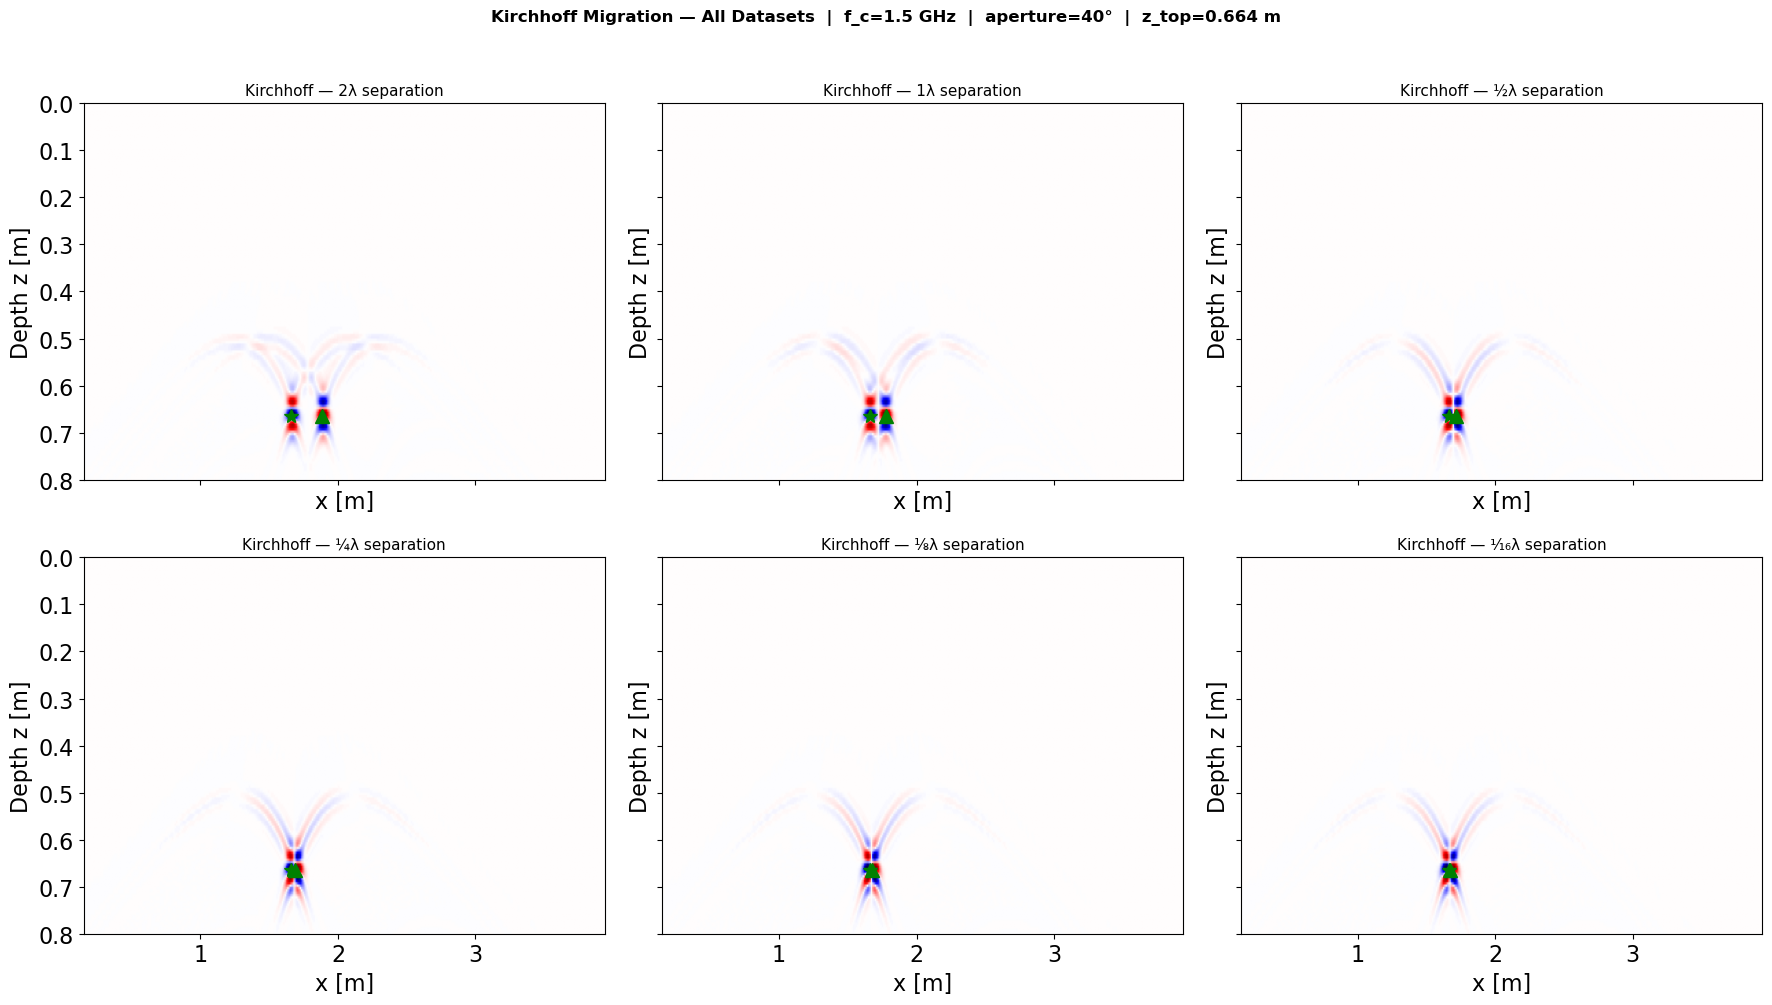

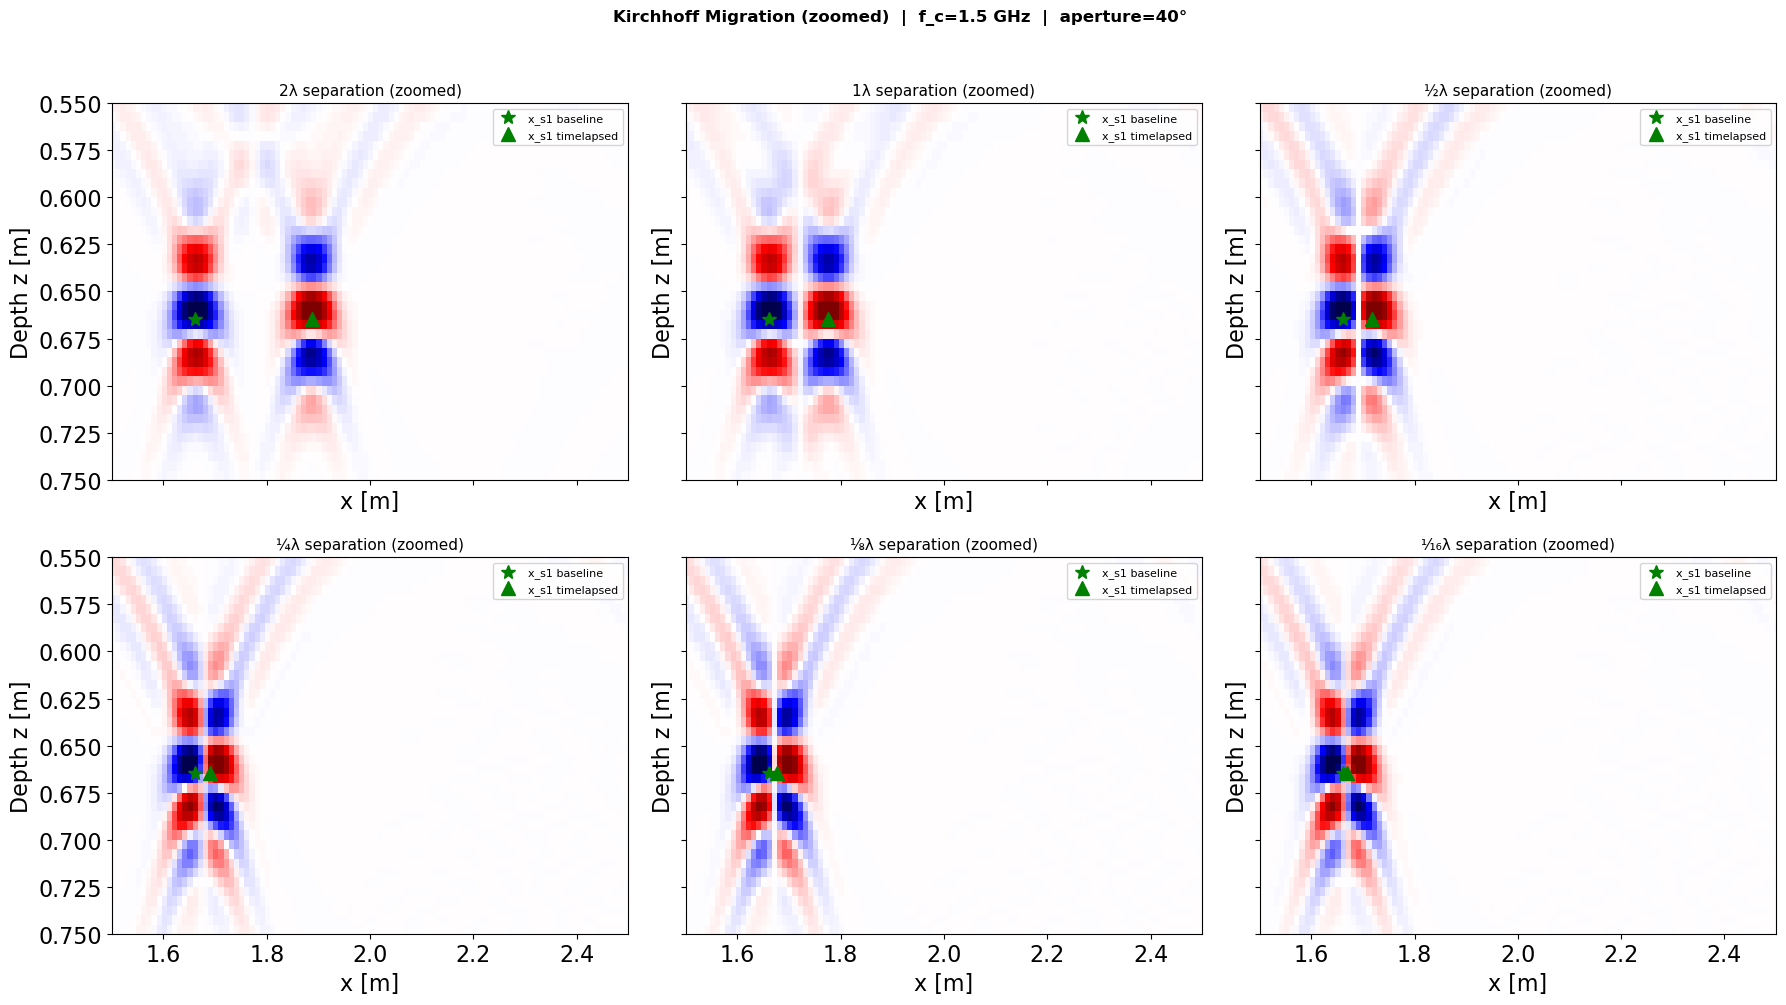

In [61]:
# ── Plot: full extent ──────────────────────────────────────────────────────────
extent_mig = [x_traces[0], x_traces[-1], z_img[-1], z_img[0]]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for i, (ax, (label, img)) in enumerate(zip(axes.ravel(), migrated.items())):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer_1[0],     z_top, 'g*', ms=10, zorder=5)
    ax.plot(x_scatterer_1[i + 1], z_top, 'g^', ms=10, zorder=5)
    ax.set_title(f'Kirchhoff — {label} separation', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')

plt.suptitle(
    f'Kirchhoff Migration — All Datasets  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP}°  |  z_top={z_top:.3f} m',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'kirchhoff_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot: zoomed on scatterer region ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for i, (ax, (label, img)) in enumerate(zip(axes.ravel(), migrated.items())):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer_1[0],     z_top, 'g*', ms=10, zorder=5, label='x_s1 baseline')
    ax.plot(x_scatterer_1[i + 1], z_top, 'g^', ms=10, zorder=5, label='x_s1 timelapsed')
    ax.set_xlim(1.5, 2.5); ax.set_ylim(0.75, 0.55)
    ax.set_title(f'{label} separation (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'Kirchhoff Migration (zoomed)  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP}°',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'kirchhoff_all_datasets_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

# Gazdag Phase-Shift Migration

f-k domain migration via **PyLops `PhaseShift`** downward continuation.  
Uses the same preprocessed (tapered + t0-shifted) B-scans as Kirchhoff, but operates in the
frequency-wavenumber domain: each depth step phase-shifts the wavefield by `kz·dz`.

Key implementation details:
- `v_mig = v_ice / 2` (exploding-reflector half-velocity) used internally
- 100 % spatial zero-padding each side to avoid wrap-around in kx
- Evanescent bins (`|kx| > |f|/v_mig`) are zeroed **before** the depth loop to prevent smile artefacts accumulating at the t = 0 imaging condition
- Green stars mark the true cylinder-top positions

_____________
Add padding in space and time up to the next power of 2
_____________

In [62]:
import pylops

def gazdag_migration(data, x, t, z, vel):
    """
    Gazdag (1978) phase-shift migration for zero-offset post-stack data.

    data : (n_t, n_x)  B-scan, time axis first, t0-shifted
    x, t : 1-D arrays [m, ns]
    z    : 1-D depth axis [m], uniformly spaced from 0
    vel  : full medium velocity [m/ns]; v_mig = vel/2 used internally

    Returns image (n_z, n_x), peak-normalised to ±1.
    """
    n_t, n_x = data.shape
    dt    = float(t[1] - t[0])
    dx    = float(x[1] - x[0])
    dz    = float(z[1] - z[0])
    v_mig = vel / 2.0

    # Spatial cosine taper (5%) + 100% zero-pad each side → nx_pad = 3*n_x
    n_xtap  = max(3, int(0.05 * n_x))
    pad     = n_x
    sp_tap  = pylops.utils.tapers.taper2d(n_t, n_x, n_xtap)   # (n_x, n_t)
    data_sp = np.pad(
        data.T * sp_tap,   # (n_x, n_t)
        ((pad, pad), (0, 0)),
        mode='constant'
    )                      # (nx_pad, n_t)
    nx_pad = n_x + 2 * pad

    # f-kx dip filter: zero evanescent bins before migration to prevent smile artefacts
    D_fk       = np.fft.fft(np.fft.rfft(data_sp, axis=1), axis=0)   # (nx_pad, n_f)
    freq_arr   = np.fft.rfftfreq(n_t, dt)          # [GHz]
    kx_arr     = np.fft.fftfreq(nx_pad, dx)        # [1/m]
    evanescent = np.abs(kx_arr[:, None]) > np.abs(freq_arr[None, :]) / v_mig
    D_fk[evanescent] = 0.0
    data_sp = np.real(np.fft.irfft(np.fft.ifft(D_fk, axis=0), n=n_t, axis=1))

    print(f'  nx={n_x} → nx_pad={nx_pad},  evanescent bins zeroed: '
          f'{evanescent.sum()}/{evanescent.size} ({100*evanescent.mean():.1f}%)')

    # PhaseShift depth loop: downward continuation + t=0 imaging condition
    freq  = np.fft.rfftfreq(n_t, dt)
    kx    = np.fft.fftshift(np.fft.fftfreq(nx_pad, dx))
    Pop   = pylops.waveeqprocessing.PhaseShift(v_mig, dz, n_t, freq, kx)
    field = data_sp.T.ravel()   # (n_t * nx_pad,) row-major

    image = np.zeros((len(z), n_x))
    for iz in range(len(z)):
        image[iz] = np.real(field.reshape(n_t, nx_pad)[0, pad:-pad])
        if iz < len(z) - 1:
            field = Pop.H * field   # adjoint PhaseShift = downward continuation

    peak = np.max(np.abs(image))
    return image / (peak + 1e-30)

## Run Migration on All Datasets

In [63]:
# ── Gazdag phase-shift migration on all 6 datasets ────────────────────────────
migrated_gz = {}

for label, raw in zip(labels, outputs):
    _, shifted = preprocess(raw, dt_ns, t0_ns, time_ns)   # (n_tr, n_t), t0-shifted
    print(f'[{label}] Running Gazdag ...', flush=True)
    t0 = _time.perf_counter()
    img = gazdag_migration(
        shifted.T,       # (n_t, n_tr) — time first
        x_traces, time_ns, z_img, v_ice
    )
    print(f'  Done in {_time.perf_counter()-t0:.1f} s  shape={img.shape}')
    migrated_gz[label] = img

[2λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48727/2417940 (2.0%)
  Done in 85.0 s  shape=(160, 380)
[1λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48727/2417940 (2.0%)
  Done in 84.7 s  shape=(160, 380)
[½λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48727/2417940 (2.0%)
  Done in 84.2 s  shape=(160, 380)
[¼λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48727/2417940 (2.0%)
  Done in 84.1 s  shape=(160, 380)
[⅛λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48727/2417940 (2.0%)
  Done in 84.1 s  shape=(160, 380)
[¹⁄₁₆λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48727/2417940 (2.0%)
  Done in 84.1 s  shape=(160, 380)


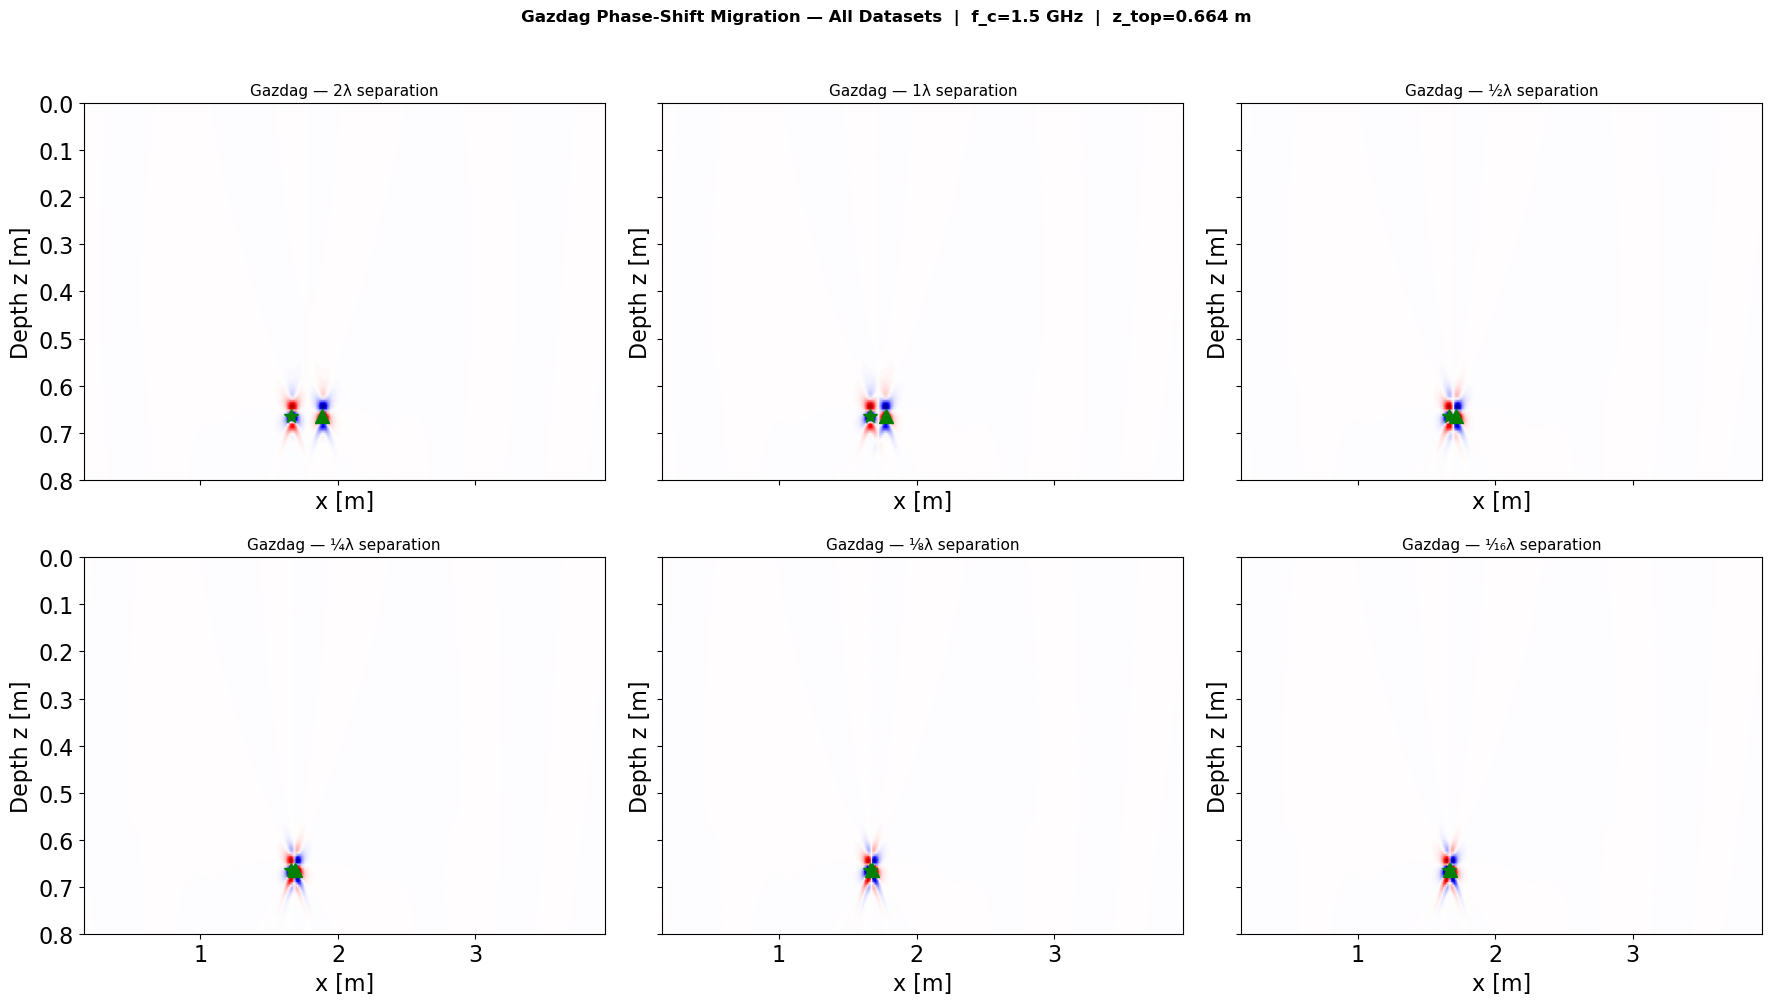

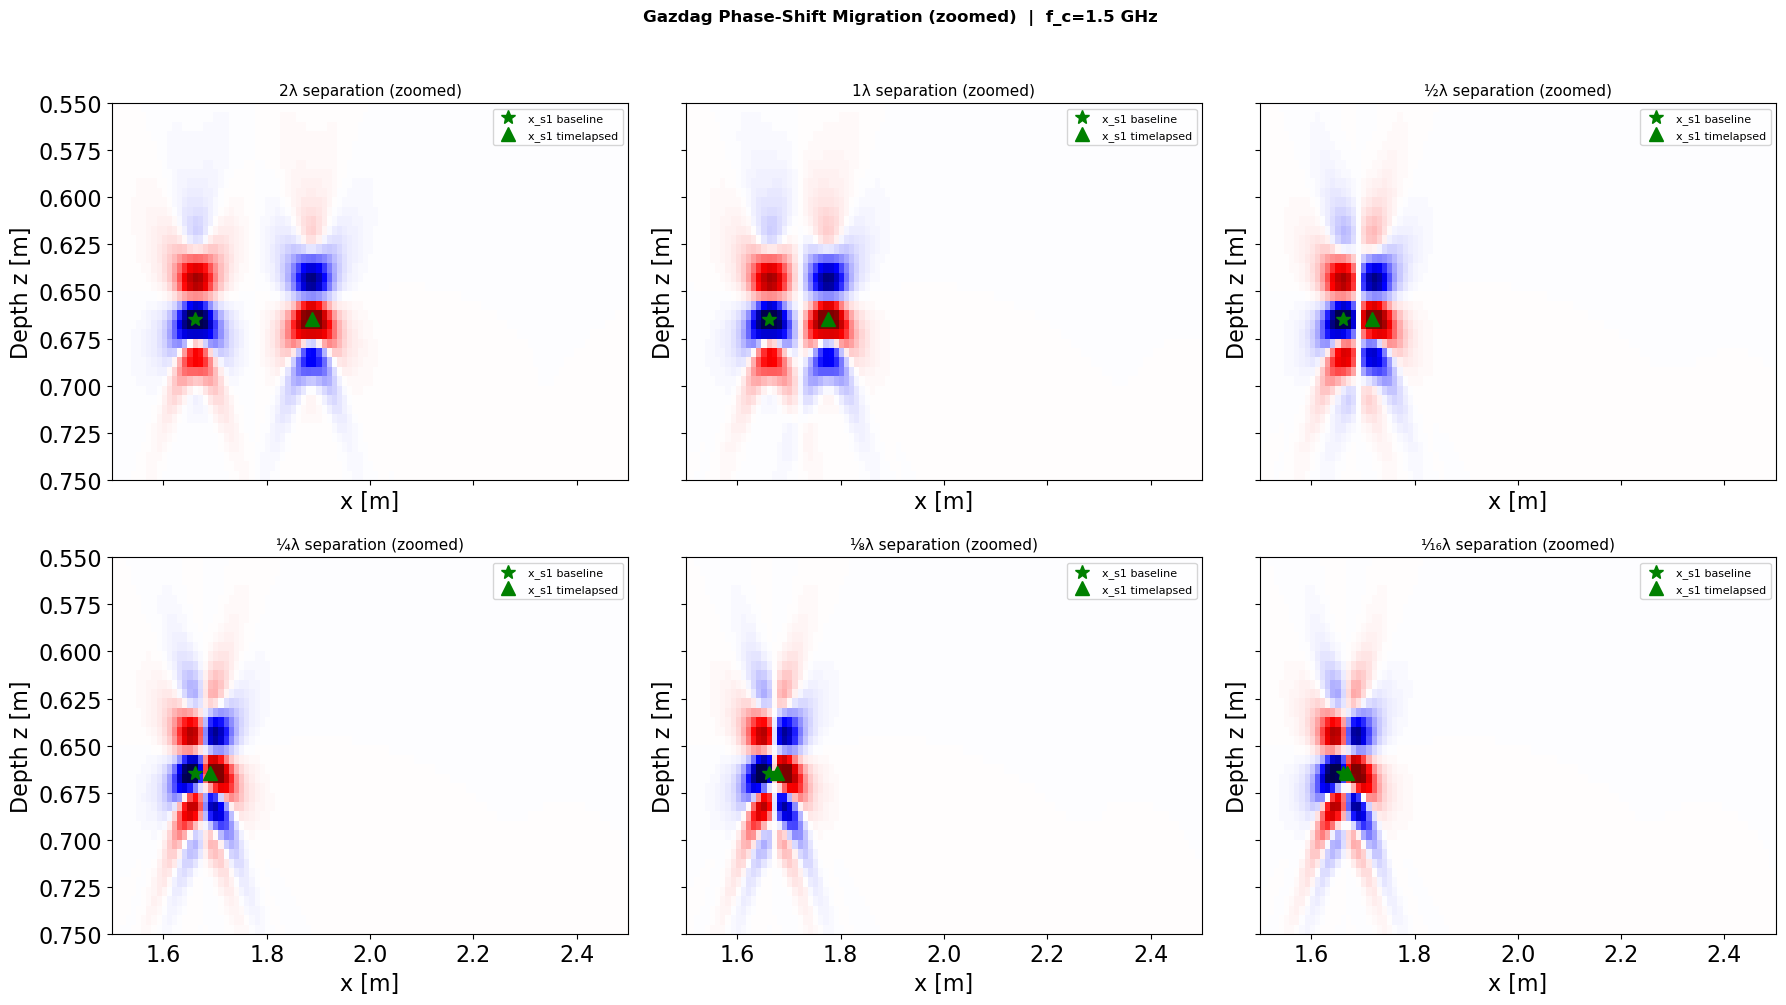

In [65]:
# ── Plot: full extent ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for i, (ax, (label, img)) in enumerate(zip(axes.ravel(), migrated_gz.items())):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer_1[0],     z_top, 'g*', ms=10, zorder=5)
    ax.plot(x_scatterer_1[i + 1], z_top, 'g^', ms=10, zorder=5)
    ax.set_title(f'Gazdag — {label} separation', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')

plt.suptitle(
    f'Gazdag Phase-Shift Migration — All Datasets  |  f_c={f_c_GHz} GHz  |  z_top={z_top:.3f} m',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'gazdag_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot: zoomed on scatterer region ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for i, (ax, (label, img)) in enumerate(zip(axes.ravel(), migrated_gz.items())):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer_1[0],     z_top, 'g*', ms=10, zorder=5, label='x_s1 baseline')
    ax.plot(x_scatterer_1[i + 1], z_top, 'g^', ms=10, zorder=5, label='x_s1 timelapsed')
    ax.set_xlim(1.5, 2.5); ax.set_ylim(0.75, 0.55)
    ax.set_title(f'{label} separation (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'Gazdag Phase-Shift Migration (zoomed)  |  f_c={f_c_GHz} GHz',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'gazdag_all_datasets_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

# LSM

# Back-Propagation Migration

Time-reversal migration: re-inject the time-reversed, normalised B-scan traces at the
original receiver positions through a **half-velocity medium** (eps_r × 4 so v → v_ice/2).

Under the exploding-reflector hypothesis every scatterer focuses simultaneously at

> **t_focus = T − t0_ns**

where T is the total simulation window. Snapshots are captured in a narrow window just
before t_focus so the collapsed wavefield image can be extracted.

| Parameter | Value |
|-----------|-------|
| Injection positions | Rx locations (Tx + 0.1 m offset) |
| Medium | eps_r × 4 → v = v_ice / 2 |
| Source stride | every `STRIDE`-th trace (tunes performance vs coverage) |

In [71]:
# ── Parameters ──────────────────────────────────────────────────────
# For zero-offset backpropagation with v_mig = v/2 (exploding-reflector),
# sources must be placed at the Tx-Rx MIDPOINTS, not at the Rx positions.
# Using Rx positions (offset +0.05 m) while keeping half-velocity causes a
# systematic lateral shift of rx_offset/2 in the focused image.
slugs  = ['2lambda', '1lambda', '0p5lambda', '0p25lambda', '0p125lambda', '0p0625lambda']
STRIDE   = 1    # use every Nth trace — reduces gprMax source count
N_SNAP   = 30   # number of snapshots in the focus window
SNAP_WIN = 1.0  # [ns] window before focus time to capture

def write_backprop_files(label, slug, tapered_ntr_nt, dt_ns, x_midpoints):
    """
    Write gprMax excitation file and .in file for back-propagation migration.
    Files go in STUDY_ROOT/backprop/<slug>/.

    Sources are placed at the Tx-Rx midpoints (x_traces), consistent with the
    exploding-reflector half-velocity (v_mig = v/2) assumption: the data is
    attributed to the midpoint, so injecting there + using v/2 focuses the
    wavefield at the true scatterer positions without lateral offset.

    Returns (in_path, n_src, n_snaps, t_focus_ns).
    """
    out_dir = STUDY_ROOT / 'backprop' / slug
    out_dir.mkdir(parents=True, exist_ok=True)

    n_tr, n_t = tapered_ntr_nt.shape
    dt_s  = dt_ns * 1e-9
    T_ns  = n_t * dt_ns

    # Stride, time-reverse, normalise per trace
    data_s   = tapered_ntr_nt[::STRIDE]
    x_src    = x_midpoints[::STRIDE]   # midpoints, NOT Rx positions
    n_src    = len(x_src)
    data_rev = data_s[:, ::-1].copy()
    peak     = np.max(np.abs(data_rev), axis=1, keepdims=True)
    peak[peak == 0] = 1.0
    data_rev /= peak

    # Snapshot timing: all depths focus simultaneously at t_focus = T - t0
    t_focus_ns = T_ns - t0_ns
    t_start_ns = max(0.0, t_focus_ns - SNAP_WIN)
    t_start_s  = t_start_ns * 1e-9
    snap_step  = max(1, int((T_ns * 1e-9 - t_start_s) / (max(1, N_SNAP - 1) * dt_s)))
    n_snaps    = max(1, int((n_t * dt_s - t_start_s) / (snap_step * dt_s)))

    # Excitation file: rows = time steps, cols = [time, src_0, ..., src_n]
    exc_path = out_dir / 'excitation.txt'
    time_s   = np.arange(n_t) * dt_s
    N_PAD    = 10
    pad_t    = np.arange(n_t, n_t + N_PAD) * dt_s
    exc_arr  = np.vstack([
        np.column_stack([time_s, data_rev.T]),
        np.column_stack([pad_t,  np.zeros((N_PAD, n_src))]),
    ])
    header = 'time ' + ' '.join(f'bp_{i}' for i in range(n_src))
    np.savetxt(exc_path, exc_arr, fmt='%.6e', header=header, comments='')

    # Source x-positions (loaded at gprMax runtime)
    npy_path = out_dir / 'src_positions.npy'
    np.save(npy_path, x_src)

    # Write .in file
    EPS_R_HALF = 4.0 * eps_r
    v_half     = v_ice / 2
    in_path    = out_dir / f'backprop_{slug}.in'

    in_lines = [
        f'#title: Back-Propagation -- {label} separation',
        '#domain: 4.000 1.000 0.002',
        '#dx_dy_dz: 0.002 0.002 0.002',
        f'#time_window: {n_t * dt_s:.6e}',
        '#pml_cells: 10 10 0 10 10 0',
        '',
        f'// Half-velocity: eps_r={EPS_R_HALF:.2f} (=4x{eps_r}) -> v={v_half:.5f} m/ns',
        f'#material: {EPS_R_HALF:.2f} 1e-6 1.0 0 ice',
        '',
        '#box: 0 0 0 4.000 0.900 0.002 ice',
        '',
        f'#excitation_file: {exc_path.name}',
        '',
        f'// {n_src} time-reversed sources at Tx-Rx midpoints (zero-offset convention, stride={STRIDE})',
        '#python:',
        'from gprMax.input_cmd_funcs import *',
        'import numpy as np',
        f"x_sources = np.load(r'{npy_path}')",
        'for i, x in enumerate(x_sources):',
        "    hertzian_dipole('z', float(x), 0.900, 0.0, 'bp_{}'.format(i))",
        '#end_python:',
        '',
        f'// {n_snaps} snapshots  window=[{t_start_ns:.1f}, {T_ns:.1f}] ns  focus at {t_focus_ns:.2f} ns',
        '#python:',
        'from gprMax.input_cmd_funcs import *',
        f't_start = {t_start_s:.8e}',
        f'step    = {snap_step}',
        f'dt_gpr  = {dt_s:.8e}',
        f'n_snap  = {n_snaps}',
        'for k in range(n_snap):',
        '    t_snap = t_start + k * step * dt_gpr',
        "    print('#snapshot: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 %.8e bp_snap%04d' % (t_snap, k+1))",
        '#end_python:',
        '',
        '#messages: y',
    ]
    in_path.write_text('\n'.join(in_lines) + '\n')
    return in_path, n_src, n_snaps, t_focus_ns

# ── Generate files for all 6 datasets ────────────────────────────────────────────
print(f'Back-propagation file generation  (stride={STRIDE}, {N_SNAP} snapshots)\n')
bp_paths = {}
for label, slug, raw in zip(labels, slugs, outputs):
    tapered, _ = preprocess(raw, dt_ns, t0_ns, time_ns)
    in_path, n_src, n_snaps, t_focus = write_backprop_files(
        label, slug, tapered, dt_ns, x_traces   # x_traces = midpoints
    )
    bp_paths[label] = in_path
    exc_mb = (in_path.parent / 'excitation.txt').stat().st_size / 1e6
    print(f'  [{label}]  {n_src} sources  |  {n_snaps} snapshots  |  '
          f'focus={t_focus:.2f} ns  |  excitation={exc_mb:.1f} MB')
    print(f'           {in_path}')


Back-propagation file generation  (stride=1, 30 snapshots)

  [2λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=21.3 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\timelapse_study\backprop\2lambda\backprop_2lambda.in
  [1λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=21.3 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\timelapse_study\backprop\1lambda\backprop_1lambda.in
  [½λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=21.3 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\timelapse_study\backprop\0p5lambda\backprop_0p5lambda.in
  [¼λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=21.3 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\timelapse_study\backprop\0p25lambda\backprop_0p25lambda.in
  [⅛λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=21.3 MB
           C:\Users\Administrator\OneDrive\

Found 29 snapshots in backprop_0p25lambda_snaps/
Focus time      : 19.06 ns
Snapshot window : 18.06 → 19.91 ns
Loaded 29 snapshots  |  shape: (500, 2000)
Focus snapshot  : idx=21  t=19.450 ns  (Δ=+0.387 ns)


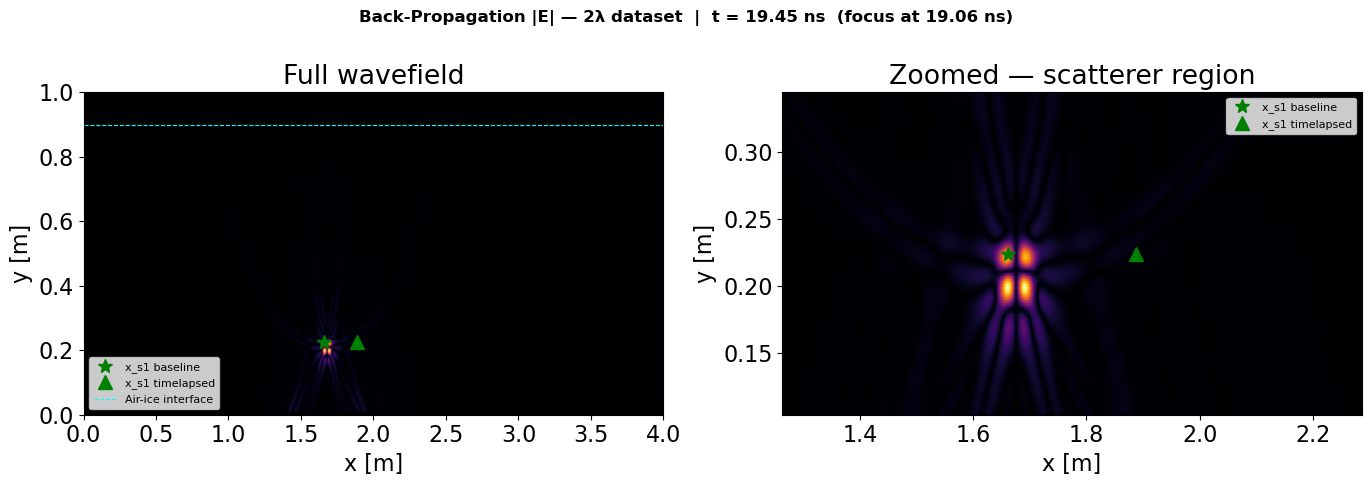

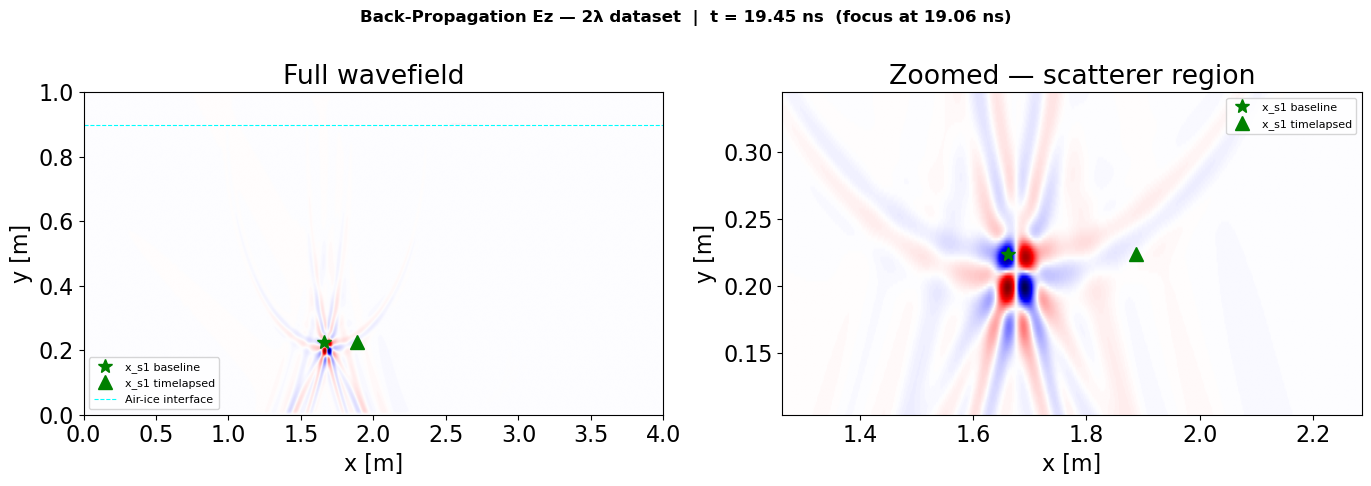

In [80]:
import pyvista

# ── Locate 2λ snapshot files ────────────────────────────────────
slug_2lam = slugs[3]   # '2lambda'
snap_dir  = STUDY_ROOT / 'backprop' / slug_2lam / f'backprop_{slug_2lam}_snaps'

snap_files = sorted(
    snap_dir.glob('bp_snap*.vti'),
    key=lambda p: int(p.stem.replace('bp_snap', ''))
)
print(f'Found {len(snap_files)} snapshots in {snap_dir.name}/')

if not snap_files:
    print('No snapshot files found. Run the gprMax cell above first.')
else:
    # Reconstruct snapshot times
    T_ns_bp    = n_t * dt_ns
    t_focus_ns = T_ns_bp - t0_ns
    t_start_ns = max(0.0, t_focus_ns - SNAP_WIN)
    dt_s       = dt_ns * 1e-9
    snap_step  = max(1, int((T_ns_bp*1e-9 - t_start_ns*1e-9) / (max(1, N_SNAP - 1) * dt_s)))
    snap_times_ns = t_start_ns + np.arange(len(snap_files)) * snap_step * dt_ns

    print(f'Focus time      : {t_focus_ns:.2f} ns')
    print(f'Snapshot window : {snap_times_ns[0]:.2f} → {snap_times_ns[-1]:.2f} ns')

    # Load |E| and Ez from every snapshot
    # VTI grid: 2000 x-cells × 500 y-cells × 1 z-cell
    # mesh['E-field'] shape: (1_000_000, 3) → reshape to (ny=500, nx=2000)
    snaps_mag = []
    snaps_ez  = []
    for p in snap_files:
        mesh   = pyvista.read(str(p))
        e_data = np.array(mesh['E-field'])                          # (n_pts, 3)
        snaps_mag.append(np.linalg.norm(e_data, axis=1).reshape(500, 2000))
        snaps_ez.append(e_data[:, 2].reshape(500, 2000))
    snaps_mag = np.stack(snaps_mag)   # (n_snap, ny, nx)
    snaps_ez  = np.stack(snaps_ez)    # (n_snap, ny, nx)
    print(f'Loaded {len(snaps_mag)} snapshots  |  shape: {snaps_mag[0].shape}')

    # Select the snapshot closest to the focus time
    idx_focus  = int(np.argmin(np.abs(snap_times_ns - t_focus_ns))) + 6
    focus_mag  = snaps_mag[idx_focus]
    focus_ez   = snaps_ez[idx_focus]
    t_actual   = snap_times_ns[idx_focus]
    print(f'Focus snapshot  : idx={idx_focus}  t={t_actual:.3f} ns  (Δ={t_actual-t_focus_ns:+.3f} ns)')

    # Scatterer positions for 2λ dataset (slugs[0] → x_scatterer_1 index 1)
    x_bp_baseline   = x_scatterer_1[0]   # baseline left scatterer
    x_bp_timelapsed = x_scatterer_1[1]   # timelapsed left scatterer (2λ)

    extent_full = [0, 4.0, 0, 1]   # full gprMax domain [m]
    margin_x    = 0.4
    margin_y    = 0.12

    def _plot_pair(img, cmap, vmin, vmax, title_prefix):
        fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(14, 5))

        for ax in (ax_full, ax_zoom):
            ax.imshow(img, aspect='auto', cmap=cmap,
                      extent=extent_full, origin='lower')
            ax.plot(x_bp_baseline,   y_scatterer, 'g*', ms=10, zorder=5, label='x_s1 baseline')
            ax.plot(x_bp_timelapsed, y_scatterer, 'g^', ms=10, zorder=5, label='x_s1 timelapsed')
            ax.set(xlabel='x [m]', ylabel='y [m]')
            ax.legend(fontsize=8)

        ax_full.axhline(y_surface, color='cyan', lw=0.8, ls='--', label='Air-ice interface')
        ax_full.legend(fontsize=8)
        ax_full.set_title('Full wavefield')

        ax_zoom.set_xlim(x_bp_baseline - margin_x, x_bp_timelapsed + margin_x)
        ax_zoom.set_ylim(y_scatterer - margin_y, y_scatterer + margin_y)
        ax_zoom.set_title('Zoomed — scatterer region')

        plt.suptitle(
            f'{title_prefix} — 2λ dataset  |  '
            f't = {t_actual:.2f} ns  (focus at {t_focus_ns:.2f} ns)',
            fontsize=12, fontweight='bold'
        )
        plt.tight_layout()
        return fig

    # ── Figure 1: |E| magnitude (inferno) ────────────────────────────────
    vmax_mag = np.percentile(focus_mag, 99.5)
    fig = _plot_pair(focus_mag, 'inferno', 0, vmax_mag, 'Back-Propagation |E|')
    fig.savefig(snap_dir / 'backprop_focus_mag.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Figure 2: Ez component (seismic) ─────────────────────────────────
    vmax_ez = np.percentile(np.abs(focus_ez), 99.5)
    fig = _plot_pair(focus_ez, 'seismic', -vmax_ez, vmax_ez, 'Back-Propagation Ez')
    fig.savefig(snap_dir / 'backprop_focus_ez.png', dpi=150, bbox_inches='tight')
    plt.show()